https://www.kaggle.com/competitions/deceptive-points-aicc-round-0/overview

In [11]:
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression, Ridge, RANSACRegressor
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

train = pd.read_csv("/kaggle/input/deceptive-points-aicc-round-0/train.csv")
test = pd.read_csv("/kaggle/input/deceptive-points-aicc-round-0/test.csv")


In [12]:
columns = train.drop(columns = ['target']).columns
columns

Index(['feature1', 'feature2', 'feature3', 'feature4'], dtype='object')

In [13]:
train

,feature1,feature2,feature3,feature4,target
0,-4.973675,7.093568,-0.153496,9.400500,-11.100981
1,0.917252,7.904774,1.189619,1.864921,9.324822
2,8.137991,-3.755653,6.936703,14.174913,-6.015563
3,8.737271,-1.220908,-3.365430,9.303323,10.848881
4,1.772946,-3.452335,5.933342,-6.867038,17.858051
...,...,...,...,...,...
175,-4.455982,2.197990,1.220006,-2.512420,-1.984108
176,9.815574,-2.346632,-10.750702,-3.551287,-3.669831
177,9.800142,-5.816334,2.859876,-0.897506,24.134472
178,6.283606,-9.987658,-2.628415,1.420140,21.020961


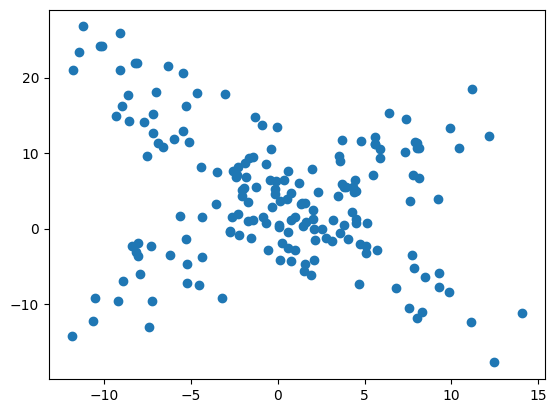

In [14]:
pca = PCA(n_components = 1)
features = pca.fit_transform(train.drop(columns = ['target']))
plt.scatter(features[:, 0], train['target'])

In [15]:
from xgboost import XGBRegressor
model = RANSACRegressor()
model.fit(train.drop(columns = ['target']), train['target'])

RANSACRegressor()

In [16]:
test

,ID,feature1,feature2,feature3,feature4
0,0.0,9.021074,-0.474683,-1.711307,-4.038753
1,1.0,4.595930,5.294598,-3.994364,0.353434
2,2.0,-5.948350,-0.253645,-3.032465,-2.807706
3,3.0,2.547834,2.365026,-1.924122,0.725052
4,4.0,-4.875392,-2.451745,6.838744,-1.925359
...,...,...,...,...,...
115,115.0,-6.309572,-9.247554,-8.569859,5.114200
116,116.0,-1.780314,8.869493,3.992481,9.524171
117,117.0,-2.053657,2.280724,4.506916,-1.780480
118,118.0,9.818546,-4.272338,7.160811,1.724752


In [17]:
prediction = model.predict(test.drop(columns = ['ID']))

In [18]:
answer = pd.DataFrame({
    'ID': test['ID'],
    'Target':prediction
})

In [19]:
answer.to_csv("submission.csv", index = False)